In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("Warm_Up_Predict_Blood_Donations_-_Traning_Data.csv")

In [6]:
df

,Unnamed: 0,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
0,619,2,50,12500,98,1
1,664,0,13,3250,28,1
2,441,1,16,4000,35,1
3,160,2,20,5000,45,1
4,358,1,24,6000,77,0
...,...,...,...,...,...,...
571,698,23,1,250,23,0
572,433,16,3,750,86,0
573,360,21,2,500,52,0
574,541,39,1,250,39,0


In [7]:
df.head()

,Unnamed: 0,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
0,619,2,50,12500,98,1
1,664,0,13,3250,28,1
2,441,1,16,4000,35,1
3,160,2,20,5000,45,1
4,358,1,24,6000,77,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Unnamed: 0                   576 non-null    int64
 1   Months since Last Donation   576 non-null    int64
 2   Number of Donations          576 non-null    int64
 3   Total Volume Donated (c.c.)  576 non-null    int64
 4   Months since First Donation  576 non-null    int64
 5   Made Donation in March 2007  576 non-null    int64
dtypes: int64(6)
memory usage: 27.1 KB


In [9]:
df.describe()

,Unnamed: 0,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
count,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000
mean,374.034722,9.439236,5.427083,1356.770833,34.050347,0.239583
std,216.947773,8.175454,5.740010,1435.002556,24.227672,0.427200
min,0.000000,0.000000,1.000000,250.000000,2.000000,0.000000
25%,183.750000,2.000000,2.000000,500.000000,16.000000,0.000000
50%,375.500000,7.000000,4.000000,1000.000000,28.000000,0.000000
75%,562.500000,14.000000,7.000000,1750.000000,49.250000,0.000000
max,747.000000,74.000000,50.000000,12500.000000,98.000000,1.000000


In [12]:
df = df.drop(columns=['Unnamed: 0'])
df.columns = ['months_since_last_donation', 'number_of_donations', 'total_volume_donated', 'months_since_first_donation', 'made_donation_march_2007']

In [14]:
df.head()

,months_since_last_donation,number_of_donations,total_volume_donated,months_since_first_donation,made_donation_march_2007
0,2,50,12500,98,1
1,0,13,3250,28,1
2,1,16,4000,35,1
3,2,20,5000,45,1
4,1,24,6000,77,0


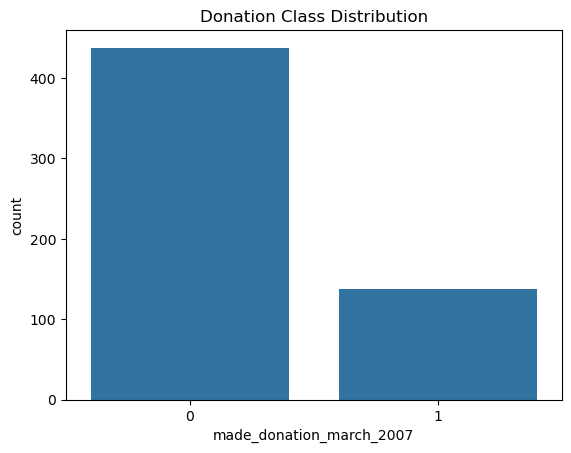

In [15]:
df['made_donation_march_2007'].value_counts()
sns.countplot(x='made_donation_march_2007', data=df)
plt.title('Donation Class Distribution')
plt.show()

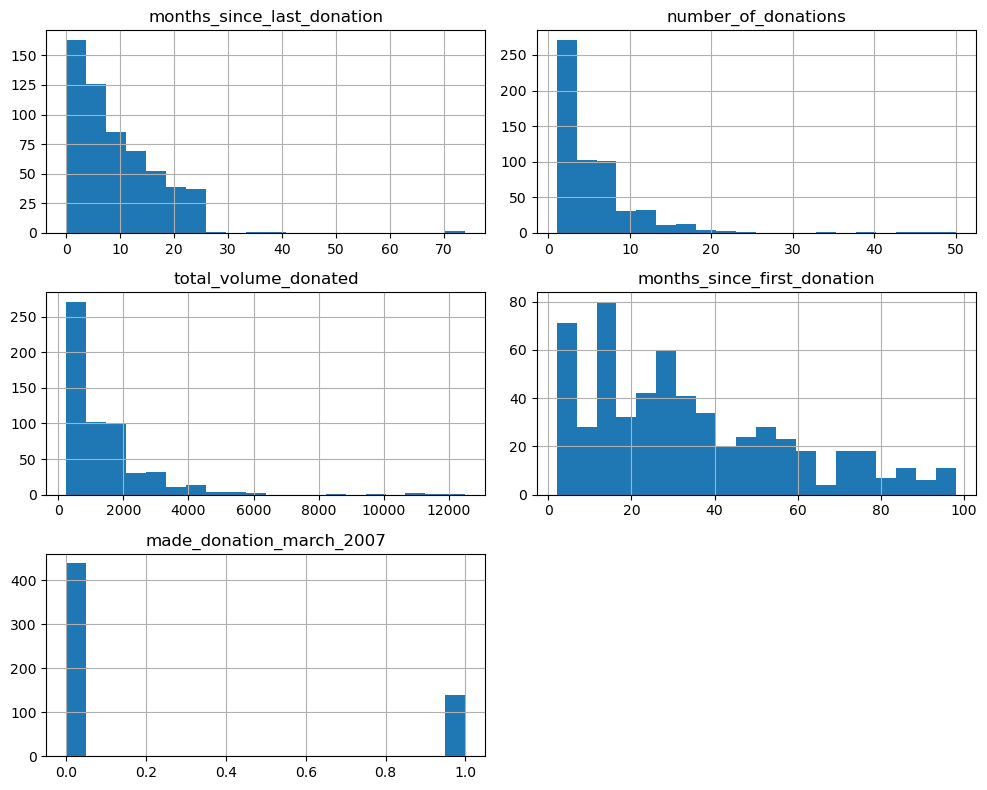

In [16]:
df.hist(figsize=(10, 8), bins=20)
plt.tight_layout()
plt.show()

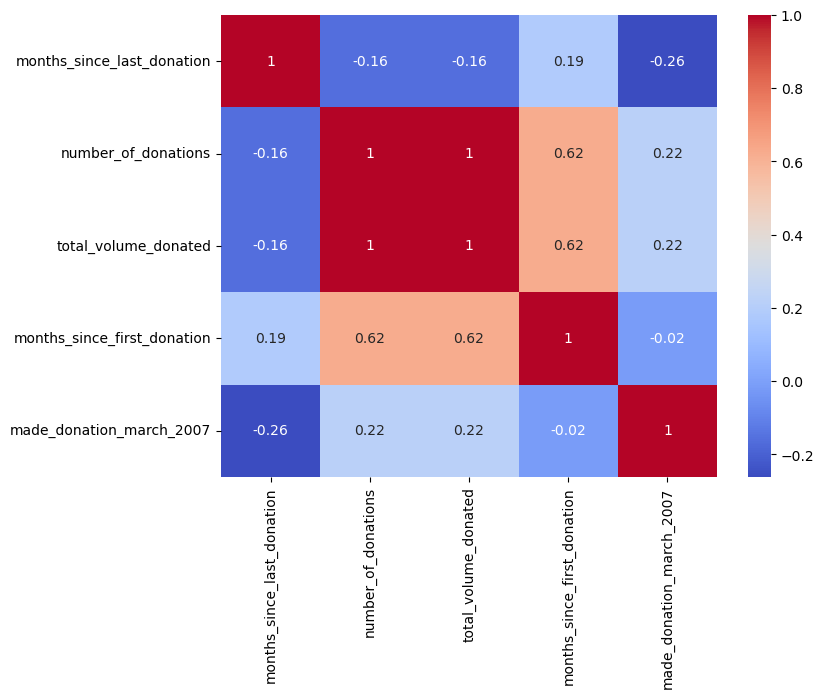

In [17]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

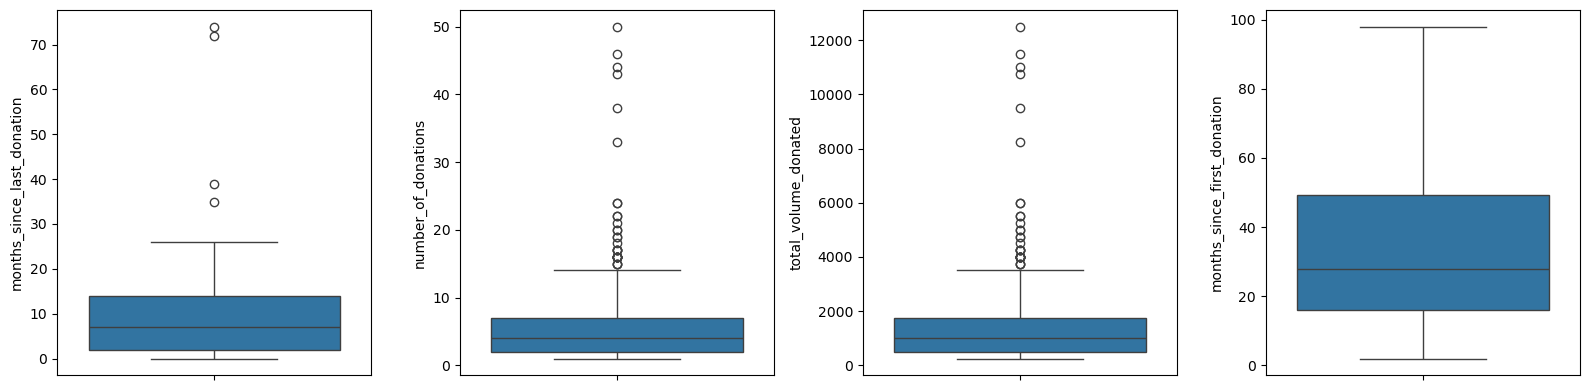

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
sns.boxplot(y=df['months_since_last_donation'], ax=axes[0])
sns.boxplot(y=df['number_of_donations'], ax=axes[1])
sns.boxplot(y=df['total_volume_donated'], ax=axes[2])
sns.boxplot(y=df['months_since_first_donation'], ax=axes[3])
plt.tight_layout()
plt.show()

In [19]:
df = df.drop(columns=['total_volume_donated'])
df.head()

,months_since_last_donation,number_of_donations,months_since_first_donation,made_donation_march_2007
0,2,50,98,1
1,0,13,28,1
2,1,16,35,1
3,2,20,45,1
4,1,24,77,0


In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x = df.drop(columns=['made_donation_march_2007'])
y = df['made_donation_march_2007']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print(x_train.shape, x_test.shape)

(460, 3) (116, 3)


In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

log_reg = LogisticRegression(random_state=42)
log_reg.fit(x_train_scaled, y_train)

dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train, y_train)

rf = RandomForestClassifier(random_state=42)
rf.fit(x_train, y_train)

print("All modes trained!")

All modes trained!


In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

models = {'Logistic Regression': log_reg, 'Decision Tree': dt, 'Random Forest': rf}

result = []

for name, model in models.items():
    if name == 'Logistic Regression':
        y_pred = model.predict(x_test_scaled)
        y_prob = model.predict_proba(x_test_scaled)[:,1]
    else:
        y_pred = model.predict(x_test)
        y_prob = model.predict_proba(x_test)[:,1]

    result.append({
            'Model':name,
            'accuracy':accuracy_score(y_test, y_pred),
            'precision':precision_score(y_test, y_pred),
            'recall':recall_score(y_test, y_pred),
            'f1 Score':f1_score(y_test, y_pred),
            'ROC-AUC':roc_auc_score(y_test, y_pred)
    })
results_df = pd.DataFrame(result)
print(results_df)

                 Model  accuracy  precision    recall  f1 Score   ROC-AUC
0  Logistic Regression  0.775862   0.625000  0.178571  0.277778  0.572240
1        Decision Tree  0.655172   0.285714  0.285714  0.285714  0.529221
2        Random Forest  0.732759   0.428571  0.321429  0.367347  0.592532


In [46]:
print(results_df.columns)

Index(['Model', 'accuracy', 'precision', 'recall', 'f1 Score', 'ROC-AUC'], dtype='object')


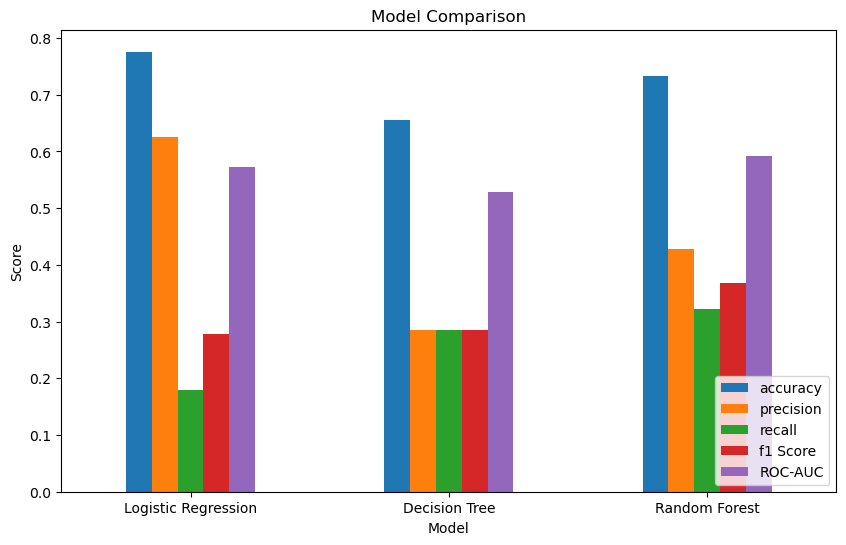

In [48]:
import matplotlib.pyplot as plt

results_df.set_index('Model')[[
    'accuracy', 'precision', 'recall', 'f1 Score', 'ROC-AUC'
]].plot(kind='bar', figsize=(10, 6))

plt.title('Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

# Data Analysis Report

## Dataset Overview
The dataset contains 576 records of blood donors from a mobile donation vehicle in Taiwan, 
with the goal of predicting whether a donor will donate again in March 2007.

## Features
- Months since Last Donation
- Number of Donations
- Total Volume Donated (removed due to perfect correlation with Number of Donations)
- Months since First Donation
- Made Donation in March 2007 (target variable)

## Key Findings
- **No missing values** — dataset was clean going in.
- **Class imbalance**: ~76% of donors did not donate again, ~24% did.
- **Multicollinearity**: Number of Donations and Total Volume Donated were perfectly 
  correlated (1.0), since volume is simply donations × a fixed amount. Total Volume 
  Donated was dropped to avoid redundancy.
- **Skewed distributions**: All numeric features are right-skewed — most donors gave 
  recently and infrequently, with a smaller group of very frequent donors.
- **Correlations with target**: Months since Last Donation has a weak negative correlation 
  (-0.26) with donating again — recent donors are more likely to return. Number of 
  Donations has a weak positive correlation (0.22).
- **Outliers**: A handful of very frequent donors appear as outliers in Number of 
  Donations, but these are legitimate data points, not errors.

# Model Comparison Report

Three classification models were trained and evaluated: Logistic Regression, 
Decision Tree, and Random Forest.

| Model | Accuracy | Precision | Recall | F1 Score | ROC-AUC |
|---|---|---|---|---|---|
| Logistic Regression | 0.776 | 0.625 | 0.179 | 0.278 | 0.572 |
| Decision Tree | 0.655 | 0.286 | 0.286 | 0.286 | 0.529 |
| Random Forest | 0.733 | 0.429 | 0.321 | 0.367 | 0.593 |

## Interpretation
Because the target classes are imbalanced (76% did not donate, 24% did), accuracy 
alone is a misleading metric — a model could score well just by predicting the 
majority class. F1 Score and ROC-AUC give a more honest picture of performance here.

- Logistic Regression has the highest accuracy but the lowest recall — it misses 
  most actual repeat donors.
- Decision Tree performs worst overall.
- **Random Forest has the best F1 Score (0.367) and ROC-AUC (0.593)**, making it the 
  most balanced and reliable model for identifying which donors are likely to return.

## Recommendation
**Random Forest is recommended for production**, as it best balances precision and 
recall, and generalizes better than a single Decision Tree.

# Report on Challenges Faced

1. **Multicollinearity**: Number of Donations and Total Volume Donated were perfectly 
   correlated (correlation = 1.0). Kept Number of Donations and dropped Total Volume 
   Donated to avoid redundant information and potential instability in linear models.

2. **Class Imbalance**: The target variable was imbalanced (~76/24 split). Addressed 
   this by using stratified train/test splitting to preserve the class ratio in both 
   sets, and by prioritizing F1 Score and ROC-AUC over raw accuracy when comparing 
   models.

3. **Outliers**: A small number of very frequent donors appeared as outliers in 
   Number of Donations and Total Volume Donated. These were kept in the dataset since 
   they represent real donor behavior rather than data entry errors.

4. **Model Selection**: Logistic Regression showed high accuracy but poor recall due 
   to the class imbalance, which could have been misleading if accuracy alone was used 
   to select the best model. Comparing multiple metrics led to correctly selecting 
   Random Forest as the best-performing model.